# 이전 문장 시제와 현재 문장, 다음 문장 시제가 계산된 파일을 바탕으로 전환률 계산

- 2.개수_생성함수_sentence_tense.ipynb 파일에서 생성한 개수 생성 csv파일을 바탕으로 작성.


### log 
- ~2026.06.14
    - 입력: "..\csv\통계용\세종_문어_문장끝_인용제외_body만_통계_20260520_16-36.csv"
    - 출력: "..\csv\결과값\tense\RUNS_A_by_docu_id_2026-05-05_17-57.csv"(document별 RUNS 전환률 계산) 등
    - 필터 적용: df_1101_V = apply_filters(df, {"f_EN_No": 1101, "f_EN_label": "EF", "dominant_EN_No": 1101, "sen_count_has_E_not_quote": lambda s: s >= 20, "VX0_No": -1})


### 4.5.1 note
- 4.5 based reusable version with odds-ratio/log-odds-ratio columns, smoothing option, separated plotting helpers, and pytest coverage.
- `smoothing` affects only the added odds-ratio/log-odds-ratio columns; existing probability, ratio, and delta formulas are unchanged.


In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
ROOT = Path.cwd().parents[0]
sys.path.append(str(ROOT))

from stats.transition_odds import add_transition_odds_columns
from stats.transition_plots import plot_transition_effect, plot_transition_binned_line

from stats.transition_analysis import analyze_trigram_from_weighted_df
from stats.transition_notebook_plots import (
    plot_prior2_probability_from_trigram_result,
    plot_1prior_T_by_units_grouped,
    plot_1prior_T_by_units,
    plot_prior2_probability_by_units,
)

CSV_PATH = Path(r"..\csv\통계용\세종_문어_문장끝_인용제외_body만_통계_20260520_16-36.csv")
        #FILTER_BODY_SEN_ENDS_NOT_QUOTE = lambda df: df[(df['sent_end_V'] == True) & (df['sent_end_V_in_quote'] == False) & (df['speaker'] == 'body')]

COUNT_MODE = "weight" #가중치 파일
WEIGHT_COL="count" #입력 파일이 이미 가중치가 적용된 형태이므로, 가중치 컬럼을 지정하여 "개수" 대신 "가중치 합계"로 계산하도록 함.

df = pd.read_csv(CSV_PATH)

print(f"CSV 파일 로드 완료: {len(df):,}, now: {datetime.now().strftime('%Y.%m.%d_%H:%M:%S')}")

if True:
        #document 파일 읽기, 'docu_었_결합_등급', 'docu_었_결합_성향' 컬럼만 추출하여 df와 병합
        DOCU_CSV = r"..\csv\original_csv\세종문어_document_정보_ver.1.2.csv"
        df_docu = pd.read_csv(DOCU_CSV, low_memory=False)
        print(f"파일 읽기 완료 - {datetime.now().strftime('%Y.%m.%d_%H:%M:%S')}")
        print(f"df_docu: {df_docu.columns.tolist()}")
        df_docu = df_docu[['docu_id', 'category', 'docu_었_결합_등급', 'docu_었_결합_성향']]

        print(f"df_docu: {df_docu.columns.tolist()}")
        df = df.merge(df_docu, on='docu_id', how='left')
        print(f"df_docu와 병합 완료 - {datetime.now().strftime('%Y.%m.%d_%H:%M:%S')}")

        # 컬럼명 중복 제거(_x, _y)
        y_cols = [c for c in df.columns if c.endswith("_y")]
        df = df.drop(columns=y_cols)
        df.columns = [c[:-2] if c.endswith("_x") else c for c in df.columns]

df.loc[df["문서범주"] == "책", "문서범주"] = "인문자연"

df['total'] = True

df.columns

CSV 파일 로드 완료: 1,022,399, now: 2026.06.20_17:35:27
파일 읽기 완료 - 2026.06.20_17:35:27
df_docu: ['docu_id', 'file_id', 'docu_num', 'category', '매체', '내용', '내용2', '파일제목', '저자', '출판사', '출판연도', 'head', '제목', '구어/문어', '분류기호', '분류기호2', '내용3', '분류기호4', 'docu_sen_count', 'docu_sen_count_has_E', 'docu_sen_count_not_quote', 'docu_sen_count_has_E_not_quote', 'docu_base_count_not_quote', 'docu_dominant_EN_No', 'docu_dominant_EN_label', 'docu_dominant_count', 'docu_dominant_ratio', 'docu_sent_count', 'docu_head_count', 'docu_body_count', 'docu_body_has_E_count', 'docu_body_not_quote_count', 'docu_body_not_quote_and_었_count', 'docu_었_결합_오즈비', 'docu_었_결합_로그오즈비', 'docu_었_결합_등급', 'docu_었_결합_성향', 'category2', 'file_sent_count', 'file_head_count', 'file_body_count', 'file_body_has_E_count', 'file_body_not_quote_count', 'file_body_not_quote_and_었_count', 'file_었_결합_오즈비', 'file_었_결합_로그오즈비', 'file_었_결합_등급', 'file_었_결합_성향']
df_docu: ['docu_id', 'category', 'docu_었_결합_등급', 'docu_었_결합_성향']
df_docu와 병합 완료 - 2026.06.

Index(['Unnamed: 0', '문서범주', 'category', '매체', 'file_id', 'docu_id', 'speaker',
       'sen_count', 'sen_count_has_E', 'sen_count_not_quote',
       'sen_count_has_E_not_quote', 'base_count_not_quote', 'dominant_EN_No',
       'dominant_EN_label', 'dominant_count', 'dominant_ratio', 'V_No',
       'V_form', 'V_label', 'EP_form', 'EN_form', 'EN_label', 'EN_No',
       'EN_No_sub', 'VX_len', 'Next_VX_No', 'Next_VX_form', 'VX0_No',
       'VX0_form', 'VX0_order', 'V0_form', 'V0_No', 'V0_label', 'f_EP_form',
       'f_EN_form', 'f_EN_No', 'f_EN_No_sub', 'f_EN_label',
       'has_prev_sentence', 'has_next_sentence', 'sentence_f_EP_form',
       'prev_sentence_f_EP_form', 'next_sentence_f_EP_form',
       'sentence_sent_end_V_in_quote', 'prev_sentence_sent_end_V_in_quote',
       'next_sentence_sent_end_V_in_quote', 'EP_TT', 'EP_T', 'EP_M', 'f_EP_TT',
       'f_EP_T', 'f_EP_M', 'sentence_f_EP_TT', 'sentence_f_EP_T',
       'sentence_f_EP_M', 'prev_sentence_f_EP_TT', 'prev_sentence_f_EP_T',
 

## Function layout

General transition analysis is imported from `stats.transition_analysis`. Unit-related workflows were moved to 4.5.2 and `stats.unit_trigram_analysis_old`.


## Current transition analysis usage

`smoothing` is used only for the added odds-ratio/log-odds-ratio columns. Existing probability, ratio, and delta formulas are left unchanged.

```python
from stats.transition_plots import plot_transition_effect

tri_df = analyze_trigram_from_weighted_df(
    df,
    state_col="sentence_f_EP_T",
    prev_state_col="prev_sentence_f_EP_T",
    next_state_col="next_sentence_f_EP_T",
    unit_col="docu_id",
    smoothing=0.5,
)

ax = plot_transition_effect(
    tri_df,
    x_col="P_T",
    y_col="switch_return_log_odds_ratio_vs_markov",
    group_col="????",
    hline=0,
)
```


In [3]:
df.head(5)

,Unnamed: 0,문서범주,category,매체,file_id,docu_id,speaker,sen_count,sen_count_has_E,sen_count_not_quote,...,prev_sentence_f_EP_TT,prev_sentence_f_EP_T,prev_sentence_f_EP_M,next_sentence_f_EP_TT,next_sentence_f_EP_T,next_sentence_f_EP_M,count,docu_었_결합_등급,docu_었_결합_성향,total
0,0,신문,보도해설,신문,AA0001,AA0001.001,body,10,9.0,9.0,...,False,False,False,False,True,False,1,3,중립,True
1,1,신문,보도해설,신문,AA0001,AA0001.001,body,10,9.0,9.0,...,False,True,False,False,False,False,1,3,중립,True
2,2,신문,보도해설,신문,AA0001,AA0001.001,body,10,9.0,9.0,...,False,True,False,False,False,False,1,3,중립,True
3,3,신문,보도해설,신문,AA0001,AA0001.001,body,10,9.0,9.0,...,False,False,False,False,True,False,1,3,중립,True
4,4,신문,보도해설,신문,AA0001,AA0001.001,body,10,9.0,9.0,...,False,False,False,False,True,False,1,3,중립,True


In [10]:
#필터 적용 및 대략적인 데이터 분포 확인``
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0]
sys.path.append(str(ROOT))
from stats.filtering import apply_filters, FilterValue, has_value, _topn_values
df_1101 = apply_filters(df, {"f_EN_No": 1101, "f_EN_label": "EF"})
df_V = apply_filters(df, {"VX0_No": -1})
df_docu_selected_V = apply_filters(df, {"dominant_EN_No": 1101, "sen_count_has_E_not_quote": lambda s: s >= 20, "VX0_No": -1})
df_docu_selected10_V = apply_filters(df, {"dominant_EN_No": 1101, "sen_count_has_E_not_quote": lambda s: s >= 10, "VX0_No": -1})

print(f"{len(df_1101):,} rows with f_EN_No=1101, label='EF'(다EF)),\n {len(df_V):,} rows with VX0_No=-1 (V),\n {len(df):,} total rows")
print(df["prev_sentence_f_EP_T"].value_counts(dropna=False), df["has_prev_sentence"].value_counts(dropna=False))
print(f"df: {len(df)} rows with unique docu_id: {df['docu_id'].nunique()}")
print(f"df_docu_selected_V: {len(df_docu_selected_V)} rows with unique docu_id: {df_docu_selected_V['docu_id'].nunique()}")
print(df["category"].value_counts(dropna=False))


834,511 rows with f_EN_No=1101, label='EF'(다EF)),
 716,183 rows with VX0_No=-1 (V),
 1,022,399 total rows
prev_sentence_f_EP_T
False    600701
True     421698
Name: count, dtype: int64 has_prev_sentence
True     980438
False     41961
Name: count, dtype: int64
df: 1022399 rows with unique docu_id: 32721
df_docu_selected_V: 500645 rows with unique docu_id: 9100
category
인문사회    314801
허구일반    289316
보도해설    171911
체험기술     88817
사설       47616
자연       32611
칼럼       27772
허구아동     27691
총류       21864
Name: count, dtype: int64


In [15]:
MOAD = "TRI_A"
UNIT_COL = 'category'#'문서범주'#'docu_id'# 'docu_id' #"file_id"#'total', 'category', 'VX_len'
SAVE_DIR = Path("..") / "csv"/"결과값"/"tense"

from datetime import datetime
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

tri_df = analyze_trigram_from_weighted_df(
    df_docu_selected10_V,
    unit_col=UNIT_COL,
)
print(f"analyze_runs_from_weighted_df 완료 - {datetime.now().strftime('%Y.%m.%d_%H:%M:%S')}")

# =========================================================
# 4. save to file
# =========================================================
# category 병합
if 'docu_id' in tri_df.columns:
    docu_info = (df[['docu_id', 'category']].drop_duplicates())

    tri_df = tri_df.merge(docu_info, on='docu_id', how='left')
#---- file name settings ----  
file_name = SAVE_DIR / f'{MOAD}_by_{UNIT_COL}_{timestamp}.csv'
tri_df.to_csv(file_name, index=False, encoding="utf-8-sig")
print(f"{datetime.now()}: Output file for pivot table: {file_name}")

c:\Users\yu2hy\OneDrive\◎2020_copus\python_2023\bareun\stats\transition_analysis.py:324: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_base_ratio"] = (
c:\Users\yu2hy\OneDrive\◎2020_copus\python_2023\bareun\stats\transition_analysis.py:313: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"Obs_{col}_rate"] = safe_div(out[col], out["n_trigrams"])
c:\Users\yu2hy\OneDrive\◎2020_copus\python_2023\bareun\stats\transition_analysis.py:315: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

analyze_runs_from_weighted_df 완료 - 2026.06.21_14:47:08
2026-06-21 14:47:08.672334: Output file for pivot table: ..\csv\결과값\tense\TRI_A_by_category_2026-06-21_14-47.csv


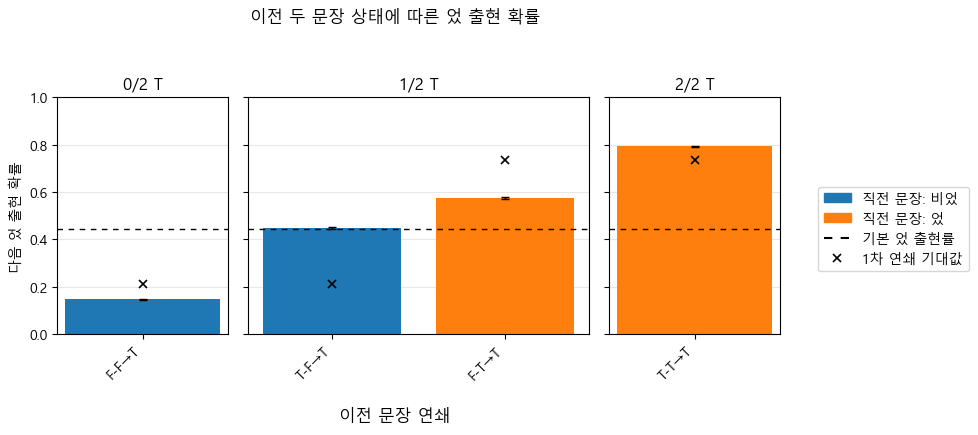

In [71]:
fig, axes, plot_df = plot_prior2_probability_from_trigram_result(
    tri_df,
    target="T",
    title="이전 두 문장 상태에 따른 었 출현 확률",
    #xlabel="",
    ylabel="다음 었 출현 확률",
    x_super_label="이전 문장 연쇄",
    base_P_label = "기본 었 출현률",
    Markov_label = "1차 연쇄 기대값"

)
plt.show()

C:\Users\yu2hy\AppData\Local\Temp\ipykernel_76924\1075767618.py:258: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_base_ratio"] = (
C:\Users\yu2hy\AppData\Local\Temp\ipykernel_76924\1075767618.py:247: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"Obs_{col}_rate"] = safe_div(out[col], out["n_trigrams"])
C:\Users\yu2hy\AppData\Local\Temp\ipykernel_76924\1075767618.py:249: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

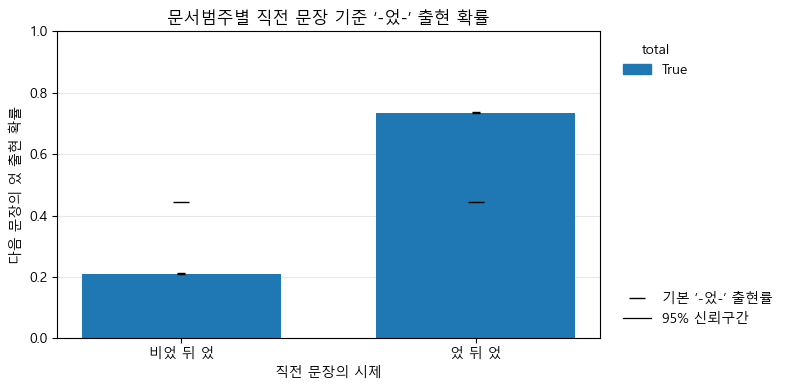

In [92]:
tri_df_total = analyze_trigram_from_weighted_df(
    df_docu_selected_V,
    unit_col="total",
)
fig, ax = plot_1prior_T_by_units_grouped(
    tri_df_total,
    unit_col="total",
    title="문서범주별 직전 문장 기준 ‘-었-’ 출현 확률",
    show_ci=True
)

plt.show()

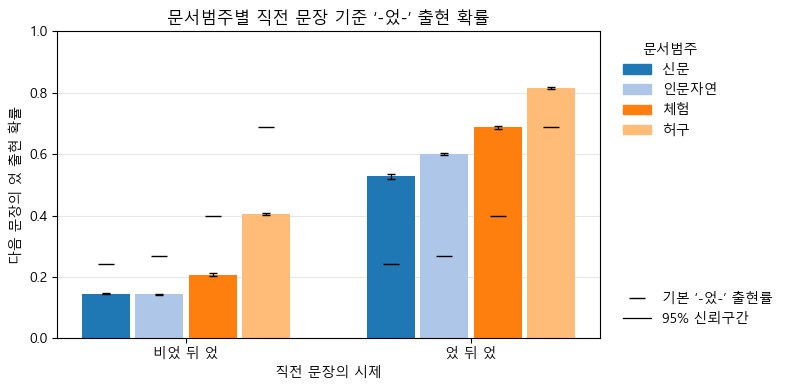

In [93]:
fig, ax = plot_1prior_T_by_units_grouped(
    tri_df,
    unit_col=UNIT_COL,
    title="문서범주별 직전 문장 기준 ‘-었-’ 출현 확률",
    show_ci=True
)

plt.show()

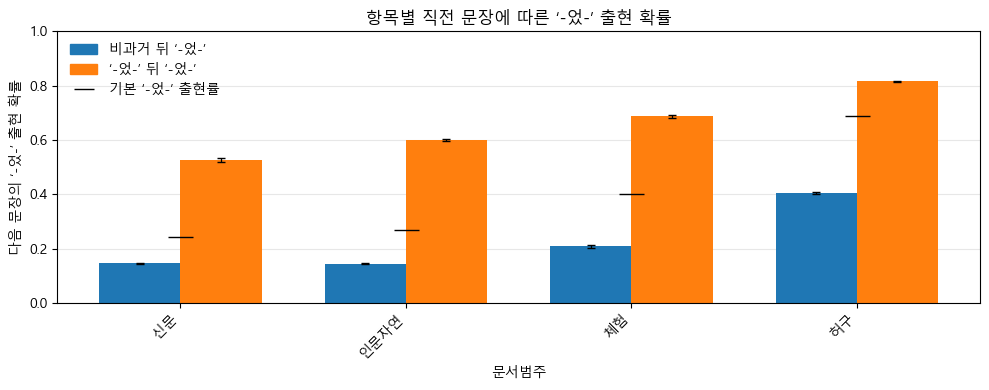

In [84]:
fig, ax = plot_1prior_T_by_units(
    tri_df,
    unit_col=UNIT_COL,
    title="항목별 직전 문장에 따른 ‘-었-’ 출현 확률",
    show_ci=True,

)
plt.show()

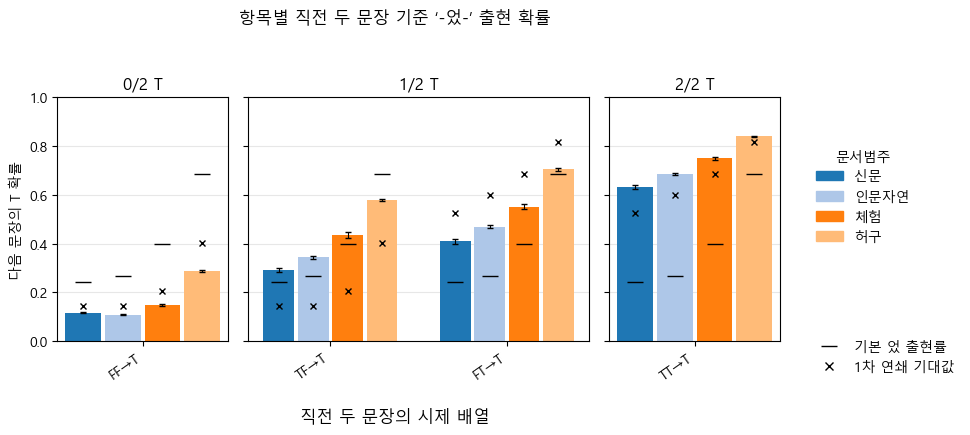

In [94]:
fig, axes = plot_prior2_probability_by_units(
    tri_df,
    unit_col=UNIT_COL,
    target="T",
    title="항목별 직전 두 문장 기준 ‘-었-’ 출현 확률",
    label_style="symbol",
    figsize=(8, 4)
)

plt.show()

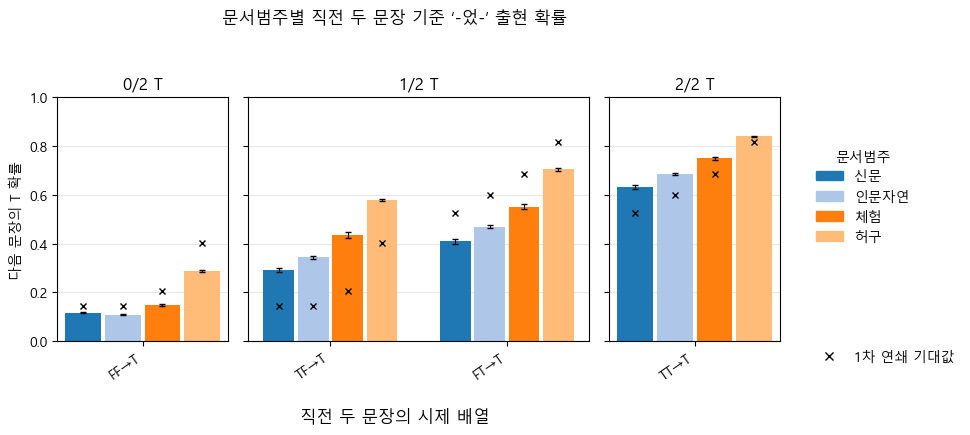

In [89]:
fig, axes = plot_prior2_probability_by_units(
    tri_df,
    unit_col=UNIT_COL,
    target="T",
    title="문서범주별 직전 두 문장 기준 ‘-었-’ 출현 확률",
    label_style="symbol",
    show_base=False,
    show_markov_expected=True,
    figsize=(8, 4)
)

plt.show()

In [ ]:
tri_df.head(5)

,docu_id,n_T,n_F,n_sentences,P_T,P_F,TT,TF,FT,FF,...,switch_extension_ratio_vs_baseline,stay_stay_Obs_rate,stay_stay_E_rate,stay_stay_delta_vs_baseline,stay_stay_ratio_vs_baseline,stay_switch_Obs_rate,stay_switch_E_rate,stay_switch_delta_vs_baseline,stay_switch_ratio_vs_baseline,문서범주
0,AA0001.021,1.0,20.0,21.0,0.047619,0.952381,0.0,1.0,1.0,18.0,...,1.055556,0.842105,0.847645,-0.005540,0.993464,0.052632,0.047091,0.005540,1.117647,신문
1,AA0001.065,1.0,18.0,19.0,0.052632,0.947368,0.0,1.0,1.0,16.0,...,1.062500,0.823529,0.830450,-0.006920,0.991667,0.058824,0.051903,0.006920,1.133333,신문
2,AA0001.071,6.0,18.0,24.0,0.250000,0.750000,5.0,1.0,0.0,17.0,...,1.000000,0.909091,0.916667,-0.007576,0.991736,0.045455,0.037879,0.007576,1.200000,신문
3,AA0002.232,1.0,22.0,23.0,0.043478,0.956522,0.0,1.0,1.0,20.0,...,1.050000,0.857143,0.861678,-0.004535,0.994737,0.047619,0.043084,0.004535,1.105263,신문
4,AA0003.001,6.0,25.0,31.0,0.193548,0.806452,4.0,2.0,2.0,22.0,...,1.263158,0.724138,0.755747,-0.031609,0.958175,0.137931,0.106322,0.031609,1.297297,신문


In [ ]:
df.columns

Index(['Unnamed: 0', '문서범주', 'category', '매체', 'file_id', 'docu_id', 'speaker',
       'sen_count', 'sen_count_has_E', 'sen_count_not_quote',
       'sen_count_has_E_not_quote', 'base_count_not_quote', 'dominant_EN_No',
       'dominant_EN_label', 'dominant_count', 'dominant_ratio', 'V_No',
       'V_form', 'V_label', 'EP_form', 'EN_form', 'EN_label', 'EN_No',
       'EN_No_sub', 'VX_len', 'Next_VX_No', 'Next_VX_form', 'VX0_No',
       'VX0_form', 'VX0_order', 'V0_form', 'V0_No', 'V0_label', 'f_EP_form',
       'f_EN_form', 'f_EN_No', 'f_EN_No_sub', 'f_EN_label',
       'has_prev_sentence', 'has_next_sentence', 'sentence_f_EP_form',
       'prev_sentence_f_EP_form', 'next_sentence_f_EP_form',
       'sentence_sent_end_V_in_quote', 'prev_sentence_sent_end_V_in_quote',
       'next_sentence_sent_end_V_in_quote', 'EP_TT', 'EP_T', 'EP_M', 'f_EP_TT',
       'f_EP_T', 'f_EP_M', 'sentence_f_EP_TT', 'sentence_f_EP_T',
       'sentence_f_EP_M', 'prev_sentence_f_EP_TT', 'prev_sentence_f_EP_T',
 